# Chapter 3: Essential Math for QC

---

Quantum computing is, at its core, a linear-algebra machine over the complex numbers: every quantum state is a vector, every operation is a matrix, and measuring an observable is an eigenvalue problem *(Book §3, intro)*. This notebook builds that foundation with short, runnable NumPy examples — complex numbers, inner products, outer products and reflection operators, tensor products, conjugate transposes, determinants and inverses, eigenvalue decomposition, matrix polynomials and exponentials, the SVD, and the Gershgorin bound.

The chapter deliberately treats **two** matrix families side by side: the real-valued symmetric matrices arising from engineering discretizations (truss, Poisson, plane stress) and the complex-valued Hermitian and unitary matrices of quantum mechanics. They share one toolkit under the mapping *Real → Complex, Transpose → Conjugate transpose, Symmetric → Hermitian, Orthogonal → Unitary*.

**Prerequisites:**
- See `Chapter02_QuantumSoftware_notebook.ipynb` for installation instructions

## Setup for Google Colab; no impact when executed on local machine

In [ ]:
import os, sys
 
if "google.colab" in sys.modules:
    if not os.path.isdir("/content/AppliedQC"):
        !git clone -q --depth 1 https://github.com/UW-ERSL/AppliedQC.git /content/AppliedQC
    exec(open("/content/AppliedQC/colab_setup.py").read())
 

In [1]:
# Setup and imports
import numpy as np
import matplotlib.pyplot as plt


## Creating complex numbers  *(Book §3.2, Example 3.1, Listing 3.1)*
Quantum amplitudes are complex numbers, and complex interference is the mechanism behind most quantum speedups. For $x = a + bi$, the real part is $a$, the imaginary part is $b$, the conjugate is $x^{*}=a-bi$, and the magnitude is $|x|=\sqrt{xx^{*}}=\sqrt{a^2+b^2}$. In Python the symbol `j` denotes $i=\sqrt{-1}$ (note the literal `3j`); we reserve `j` for this purpose and never use it as a variable or loop index. Here $x=1+3i$, so $x^{*}=1-3i$ and $|x|=\sqrt{10}$.

In [2]:
#%% Complex variables
x = 1 + 3j # note the 3j
print("The real part is: ", x.real)
print("The imaginary part is: ", x.imag)
print("The absolute value is: ", abs(x))
print("The conjugate is: ", x.conjugate())

The real part is:  1.0
The imaginary part is:  3.0
The absolute value is:  3.1622776601683795
The conjugate is:  (1-3j)


## Inner product  *(Book §3.3, Definitions 3.1–3.4, Example 3.4, Listing 3.2)*
The inner product of two vectors is $\langle u,v\rangle \equiv u^{\dagger}v = \sum_i u_i^{*}\,v_i$, built on the conjugate transpose $u^{\dagger}$. It is a complex number, and in general $\langle u,v\rangle=\langle v,u\rangle^{*}$. The two vectors here, $v_0=\tfrac{1}{\sqrt2}\begin{bmatrix}1\\1\end{bmatrix}$ and $v_1=\tfrac{1}{\sqrt2}\begin{bmatrix}1\\-1\end{bmatrix}$, are **orthonormal**: each has unit norm and $\langle v_0,v_1\rangle=0$. Orthonormal vectors form the natural basis for quantum states (Chapter 7).

In [3]:
v0 = np.array([1/np.sqrt(2), 1/np.sqrt(2)])
v1 = np.array([1/np.sqrt(2), -1/np.sqrt(2)])

# Inner product using np.vdot (handles conjugation)
print("Inner product <v0,v0>:", np.vdot(v0, v0))
print("Inner product <v0,v1>:", np.vdot(v0, v1))

Inner product <v0,v0>: 0.9999999999999998
Inner product <v0,v1>: 0.0


## Outer products and reflection operators  *(Book §3.4, Definitions 3.6–3.7, Examples 3.5–3.6, Listing 3.3)*
The **inner product** $u^{\dagger}v$ combines two vectors into a *scalar*; reversing the order gives the **outer product** $u\,v^{\dagger}$, which is a *matrix* with entries $(u\,v^{\dagger})_{ij}=u_i v_j^{*}$. This is our tool for building operators directly from vectors. A key special case is the outer product of a **unit** vector with itself, $P=v\,v^{\dagger}$, the **projector** onto $v$ — it is Hermitian and idempotent ($P^2=P$).

From it we form two **reflections**, differing only by an overall sign: $R_{\perp}=I-2\,v v^{\dagger}$ flips the component *along* $v$ and leaves everything orthogonal to $v$ unchanged, while $R_{\parallel}=2\,v v^{\dagger}-I = -R_{\perp}$ does the opposite. Both are unitary and Hermitian with $R^2=I$. Together they are exactly the ingredients of Grover's search algorithm (Chapter 12). Note `np.outer` does *not* conjugate its second argument, so we pass `v.conj()` to get $v\,v^{\dagger}$.

In [4]:
np.set_printoptions(precision=3, suppress=True)  # tidy display of tiny fp values
# Outer product u v^dag (np.outer does not conjugate; pass v.conj())
u = np.array([1, 1j])
v = np.array([1, -1j])
print("u v^dag = \n", np.outer(u, v.conj()))

# Projector onto a unit vector w:  P = w w^dag  (Hermitian, idempotent)
w = (1/np.sqrt(2)) * np.array([1.0, 1.0])
P = np.outer(w, w.conj())
print("P = w w^dag = \n", P)
print("P^2 = P ?", np.allclose(P @ P, P))

# Reflection about the hyperplane orthogonal to w:  R_perp = I - 2P
# (unitary and Hermitian, with R^2 = I) -- the Grover building block
R_perp = np.eye(2) - 2*P
print("R_perp = I - 2P = \n", R_perp)
print("R_perp unitary?", np.allclose(R_perp.conj().T @ R_perp, np.eye(2)))
print("R_perp^2 = I ?", np.allclose(R_perp @ R_perp, np.eye(2)))

# Reflection through w itself:  R_par = 2P - I = -R_perp
R_par = 2*P - np.eye(2)
print("\nR_par = 2P - I = \n", R_par)
print("R_par = -R_perp ?", np.allclose(R_par, -R_perp))

u v^dag = 
 [[ 1.+0.j -0.+1.j]
 [ 0.+1.j -1.+0.j]]
P = w w^dag = 
 [[0.5 0.5]
 [0.5 0.5]]
P^2 = P ? True
R_perp = I - 2P = 
 [[ 0. -1.]
 [-1.  0.]]
R_perp unitary? True
R_perp^2 = I ? True

R_par = 2P - I = 
 [[-0.  1.]
 [ 1. -0.]]
R_par = -R_perp ? True


## Tensor product of vectors  *(Book §3.5, Listing 3.4)*
The tensor product $\otimes$ combines two vectors into a higher-dimensional one; for two 2-vectors it produces a 4-vector of all pairwise products. NumPy's `np.kron` implements it. Here $v_1=|0\rangle=\begin{bmatrix}1\\0\end{bmatrix}$ and $v_2=|1\rangle=\begin{bmatrix}0\\1\end{bmatrix}$, so $v_1\otimes v_2 = |01\rangle = \begin{bmatrix}0\\1\\0\\0\end{bmatrix}$ — the building block of multi-qubit states.

In [5]:
v1 = np.array([1, 0])
v2 = np.array([0, 1])
v3 = np.kron(v1, v2)
print("v3 = \n", v3)

v3 = 
 [0 1 0 0]


## Conjugate transpose of a matrix  *(Book §3.6, Definitions 3.8–3.10)*
The conjugate transpose $A^{\dagger}$ is the transpose of the complex conjugate of $A$ — the complex generalization of the ordinary transpose. A matrix is **Hermitian** if $A=A^{\dagger}$ (the complex analogue of symmetric), and **unitary** if $A^{\dagger}A=I$ (the analogue of orthogonal). Here we form $A^{T}$ and $A^{\dagger}$ for a complex matrix and compare them.

In [6]:
A = np.array([[1+1j, 2], [0, 3]])
print("A = \n", A)

# Transpose
A_T = A.T
print("A^T = \n", A_T)

A_dag = np.conjugate(A).T
print("A^dag = \n", A_dag)

A = 
 [[1.+1.j 2.+0.j]
 [0.+0.j 3.+0.j]]
A^T = 
 [[1.+1.j 0.+0.j]
 [2.+0.j 3.+0.j]]
A^dag = 
 [[1.-1.j 0.-0.j]
 [2.-0.j 3.-0.j]]


## Determinant and inverse  *(Book §3.6, Listing 3.5)*
A square matrix is invertible only if it is **non-singular**, i.e. its determinant is nonzero, and then $A^{-1}$ satisfies $AA^{-1}=I$. Direct methods (LU) cost $O(N^3)$ operations and are exact in exact arithmetic; on the large *sparse* systems of engineering their real limitation is **fill-in** — the factors acquire nonzeros where $A$ had none — which is why iterative solvers, which never form the factors, are preferred at scale. Following Listing 3.5 we use the real symmetric $A=\begin{bmatrix}2&-1\\-1&2\end{bmatrix}$, then repeat on a complex matrix to show that nothing changes.

In [7]:
# Book Listing 3.5: real symmetric example
A = np.array([[2, -1], [-1, 2]])

# Check determinant (non-zero for invertible matrix)
det_A = np.linalg.det(A)
print("det(A) = ", det_A)

# Compute inverse
A_inv = np.linalg.inv(A)
print("A^{-1} = \n", A_inv)

# Verify A * A^{-1} = I
I_check = A @ A_inv
print("A * A^{-1} = \n", I_check)
print("A A^{-1} = I ?", np.allclose(I_check, np.eye(2)))

# The same works unchanged for a complex matrix
C = np.array([[1+1j, 2], [0, 3]])
print("\ndet(C) = ", np.linalg.det(C))
print("C C^{-1} = I ?", np.allclose(C @ np.linalg.inv(C), np.eye(2)))

det(A) =  2.9999999999999996
A^{-1} = 
 [[0.667 0.333]
 [0.333 0.667]]
A * A^{-1} = 
 [[1. 0.]
 [0. 1.]]
A A^{-1} = I ? True

det(C) =  (3+3j)
C C^{-1} = I ? True


## Tensor product of matrices  *(Book §3.6, subsection "Tensor Product of Matrices")*
The construction used for vectors extends to matrices: $A\otimes B$ replaces each entry of $A$ with that scalar multiple of the whole matrix $B$, so an $M\times N$ matrix tensored with a $P\times Q$ matrix gives an $(MP)\times(NQ)$ block matrix.

Two special cases carry the weight later. $I_N\otimes A$ is **block-diagonal** — $N$ independent, non-interacting copies of $A$ — while $A\otimes I_N$ is *not*, since each entry of $A$ becomes a scaled identity block instead. The order matters, and both forms appear when stiffness matrices are written compactly (Chapter 4), a structure the matrix-encoding chapters then exploit. The last block shows the other role of the tensor product: repeatedly tensoring single-qubit ($2\times2$) operators is what builds the $2^n$-dimensional operators of an $n$-qubit system, and unitarity survives every step.

In [8]:
np.set_printoptions(precision=3, suppress=True)

# --- the 2x2 (x) 2x2 pattern from the book -------------------------------
a, b, c, d = 1, 2, 3, 4
e, f, g, h = 5, 6, 7, 8
A = np.array([[a, b], [c, d]])
B = np.array([[e, f], [g, h]])
book = np.array([[a*e, a*f, b*e, b*f],       # each entry of A scaled by all of B
                 [a*g, a*h, b*g, b*h],
                 [c*e, c*f, d*e, d*f],
                 [c*g, c*h, d*g, d*h]])
print("A (x) B =\n", np.kron(A, B))
print("matches the book's 4x4 expansion?", np.array_equal(np.kron(A, B), book))

# --- general shapes:  (M x N) (x) (P x Q)  ->  (MP x NQ) ------------------
for (M, N), (P, Q) in [((2, 3), (2, 2)), ((3, 1), (2, 4))]:
    X, Y = np.ones((M, N)), np.ones((P, Q))
    print(f"({M}x{N}) (x) ({P}x{Q})  ->  {np.kron(X, Y).shape}   expected ({M*P}x{N*Q})")

# --- Case 1: I_N (x) A  is block diagonal ---------------------------------
from scipy.linalg import block_diag
A = np.array([[2., -1.], [-1., 2.]])
K1 = np.kron(np.eye(3), A) + 0.0
print("\nI_3 (x) A =\n", K1)
print("three independent copies of A on the diagonal?",
      np.allclose(K1, block_diag(A, A, A)))

# --- Case 2: A (x) I_N  is NOT block diagonal -----------------------------
K2 = np.kron(A, np.eye(3)) + 0.0
print("\nA (x) I_3 =\n", K2)
print("block-diagonal? (is the off-diagonal 3x3 block zero?)", np.allclose(K2[:3, 3:], 0))
print("same as I_3 (x) A ?", np.allclose(K1, K2), " -- the tensor product does not commute")

# --- the 2^n structure:  n qubits from n single-qubit spaces --------------
H = np.array([[1., 1.], [1., -1.]]) / np.sqrt(2)
Hn = H
for n in range(2, 4):
    Hn = np.kron(Hn, H)
    print(f"\nH^(x){n}: shape {Hn.shape} = 2^{n} x 2^{n}   still unitary?",
          np.allclose(Hn.conj().T @ Hn, np.eye(2**n)))

A (x) B =
 [[ 5  6 10 12]
 [ 7  8 14 16]
 [15 18 20 24]
 [21 24 28 32]]
matches the book's 4x4 expansion? True
(2x3) (x) (2x2)  ->  (4, 6)   expected (4x6)
(3x1) (x) (2x4)  ->  (6, 4)   expected (6x4)

I_3 (x) A =
 [[ 2. -1.  0.  0.  0.  0.]
 [-1.  2.  0.  0.  0.  0.]
 [ 0.  0.  2. -1.  0.  0.]
 [ 0.  0. -1.  2.  0.  0.]
 [ 0.  0.  0.  0.  2. -1.]
 [ 0.  0.  0.  0. -1.  2.]]
three independent copies of A on the diagonal? True

A (x) I_3 =
 [[ 2.  0.  0. -1.  0.  0.]
 [ 0.  2.  0.  0. -1.  0.]
 [ 0.  0.  2.  0.  0. -1.]
 [-1.  0.  0.  2.  0.  0.]
 [ 0. -1.  0.  0.  2.  0.]
 [ 0.  0. -1.  0.  0.  2.]]
block-diagonal? (is the off-diagonal 3x3 block zero?) False
same as I_3 (x) A ? False  -- the tensor product does not commute

H^(x)2: shape (4, 4) = 2^2 x 2^2   still unitary? True

H^(x)3: shape (8, 8) = 2^3 x 2^3   still unitary? True


## Eigenvalue decomposition  *(Book §3.7, Listing 3.6)*
Eigen-pairs satisfy $A v_k=\lambda_k v_k$, and a diagonalizable matrix factors as $A=VDV^{-1}$ with the eigenvectors as columns of $V$ and the eigenvalues on the diagonal of $D$. For a **symmetric** matrix the eigenvalues are real and $V$ is orthogonal, giving the compact form $A=VDV^{\dagger}$. For $A=\begin{bmatrix}1.5&0.5\\0.5&1.5\end{bmatrix}$ the eigenvalues are $\lambda_0=1$ and $\lambda_1=2$. This decomposition is the key to computing matrix functions efficiently.

In [9]:
A = np.array([[1.5, 0.5],
              [0.5, 1.5]])

eigenvalues, eigenvectors = np.linalg.eig(A)

print("\nEigenvalues:")
print(eigenvalues)
print("\nEigenvectors (as columns):")
print(eigenvectors)


Eigenvalues:
[2. 1.]

Eigenvectors (as columns):
[[ 0.707 -0.707]
 [ 0.707  0.707]]


## The tridiagonal test matrix  *(Book §3.7, Table 3.1 Example 6; Exercises 3.16–3.17)*
The $(-1,2,-1)$ tridiagonal matrix from the 1-D finite-difference discretization is the canonical test problem for quantum linear solvers, and it recurs throughout the book. Its eigen-pairs have a closed form (Table 3.1):

$$\lambda_k = 2 - 2\cos\frac{(k+1)\pi}{N+1}, \qquad (v_k)_j \propto \sin\frac{(j+1)(k+1)\pi}{N+1}, \qquad j,k = 0,\ldots,N-1$$

in the book's zero-based indexing. Below we confirm the closed form numerically for $N=4$ and $N=8$. Note that `np.linalg.eig` returns eigenvalues in no particular order and eigenvector signs are arbitrary, so we sort and compare magnitudes.

In [10]:
from scipy.sparse import diags

def tridiag(N):
    return diags([-np.ones(N-1), 2*np.ones(N), -np.ones(N-1)], [-1, 0, 1]).toarray()

np.set_printoptions(precision=3, suppress=True)
for N in (4, 8):
    A = tridiag(N)
    D, V = np.linalg.eig(A)
    idx = np.argsort(D); D, V = D[idx], V[:, idx]
    k = np.arange(N)
    closed = 2 - 2*np.cos((k + 1)*np.pi/(N + 1))
    print(f"N = {N}")
    print("  numpy       :", D)
    print("  closed form :", closed)
    print("  agree?", np.allclose(D, closed))
    # eigenvectors: compare up to sign ('j' is reserved for sqrt(-1), so the
    # component index is named m here)
    m = np.arange(N)[:, None]
    Vc = np.sin((m + 1)*(k + 1)*np.pi/(N + 1))
    Vc = Vc/np.linalg.norm(Vc, axis=0)
    print("  eigenvectors agree (up to sign)?",
          np.allclose(np.abs(V), np.abs(Vc)), "\n")

N = 4
  numpy       : [0.382 1.382 2.618 3.618]
  closed form : [0.382 1.382 2.618 3.618]
  agree? True
  eigenvectors agree (up to sign)? True 

N = 8
  numpy       : [0.121 0.468 1.    1.653 2.347 3.    3.532 3.879]
  closed form : [0.121 0.468 1.    1.653 2.347 3.    3.532 3.879]
  agree? True
  eigenvectors agree (up to sign)? True 



## Matrix polynomials  *(Book §3.8, Definition 3.12, Theorem 3.1, Example 3.12, Listing 3.7)*
For a polynomial $P(x)=a_0+a_1x+\cdots+a_mx^m$, the **matrix polynomial** is $P(A)=a_0I+a_1A+\cdots+a_mA^m$. The useful fact is the **Matrix Polynomial Theorem**: if $A=VDV^{\dagger}$ then $P(A)=V\,P(D)\,V^{\dagger}$, where $P(D)=\mathrm{diag}\big(P(\lambda_0),\ldots,P(\lambda_{N-1})\big)$. In words: **applying a polynomial to a matrix applies it to each eigenvalue**, leaving the eigenvectors untouched. That is why, once an eigenvalue decomposition is in hand, $P(A)$ costs no more than evaluating the scalar polynomial on each eigenvalue — and it is the mechanism QSVT exploits (Chapter 19), where a quantum circuit applies a polynomial to the *singular* values of a matrix.

Below we evaluate $P(A)=I+2A+A^2$ two ways for the book's $A=\begin{bmatrix}2&-1\\-1&2\end{bmatrix}$ (eigenvalues $\lambda_0=1$, $\lambda_1=3$) and confirm both give $\begin{bmatrix}10&-6\\-6&10\end{bmatrix}$.

In [11]:
np.set_printoptions(precision=3, suppress=True)

# --- Book Listing 3.7 / Example 3.12: p(A) = I + 2A + A^2 -----------------
A = np.array([[2., -1.], [-1., 2.]])          # eigenvalues 1 and 3
I = np.eye(2)
p_A = I + 2*A + A @ A
print("A =\n", A)
print("p(A) = I + 2A + A^2 =\n", p_A)

# Eigenvalue property: p(A) has eigenvalues p(lambda_k)
lam, _ = np.linalg.eig(A)
print("\neigenvalues of A      :", np.sort(lam))
print("p(lambda) for each    :", np.sort(1 + 2*lam + lam**2))
print("eigenvalues of p(A)   :", np.sort(np.linalg.eigvals(p_A)))

# --- Theorem 3.1: the same answer via V P(D) V^dag ------------------------
P = lambda x: 1 + 2*x + x**2
lam, V = np.linalg.eig(A)
idx = np.argsort(lam)                          # book convention: ascending
lam, V = lam[idx], V[:, idx]
viaEVD = V @ np.diag(P(lam)) @ V.conj().T      # Theorem 3.1
print("\nTheorem 3.1  : V P(D) V^dag =\n", viaEVD)
print("lambda_0, lambda_1 =", lam, " ->  P(1), P(3) =", P(lam))
print("both routes agree?", np.allclose(p_A, viaEVD))

A =
 [[ 2. -1.]
 [-1.  2.]]
p(A) = I + 2A + A^2 =
 [[10. -6.]
 [-6. 10.]]

eigenvalues of A      : [1. 3.]
p(lambda) for each    : [ 4. 16.]
eigenvalues of p(A)   : [ 4. 16.]

Theorem 3.1  : V P(D) V^dag =
 [[10. -6.]
 [-6. 10.]]
lambda_0, lambda_1 = [1. 3.]  ->  P(1), P(3) = [ 4. 16.]
both routes agree? True


## Matrix exponential  *(Book §3.9, Definition 3.13, Theorem 3.3, Example 3.14, Listing 3.8)*
The matrix exponential is the same Taylor series with a matrix argument, $e^{A}=\sum_k A^k/k!$, and by the same eigenvalue argument $e^{A}=V e^{D} V^{\dagger}$ with $e^{D}$ taken element-wise on the diagonal. The result the rest of the book leans on is **Theorem 3.3: if $A$ is Hermitian, then $e^{iA}$ is unitary** — this is why quantum gates can be written as matrix exponentials, and why $e^{-iAt}$ (quantum time evolution) is a legal operation.

We check three things: that $e^{i\theta Y}=I\cos\theta+iY\sin\theta$ is the real rotation matrix $\begin{bmatrix}\cos\theta&\sin\theta\\-\sin\theta&\cos\theta\end{bmatrix}$ (Example 3.14); that the Hermitian hypothesis in Theorem 3.3 is doing real work; and Exercise 3.23, $e^{i\pi A/2}$. Note `scipy.linalg.expm` computes the true matrix exponential — `np.exp` would exponentiate element-wise, which is a different and wrong thing.

In [12]:
from scipy.linalg import expm

# --- Book Listing 3.8: e^D is element-wise on the diagonal ----------------
D = np.diag([1., 2.])
print("exp(D) =\n", expm(D), "   (e^1 =", round(np.e, 3), ", e^2 =", round(np.e**2, 3), ")")

# --- Book Example 3.14:  e^{i theta Y} = I cos(theta) + i Y sin(theta) ----
Y = np.array([[0, -1j], [1j, 0]])
theta = np.pi/4

U_expm    = expm(1j*theta*Y)
U_formula = np.eye(2)*np.cos(theta) + 1j*Y*np.sin(theta)
U_rot     = np.array([[np.cos(theta),  np.sin(theta)],
                      [-np.sin(theta), np.cos(theta)]])
print("\nexp(i.theta.Y) via expm =\n", U_expm)
print("I cos+ iY sin          =\n", U_formula)
print("rotation matrix form   =\n", U_rot)
print("all three agree?", np.allclose(U_expm, U_formula) and np.allclose(U_expm, U_rot))
print("purely real?", np.allclose(U_expm.imag, 0), "| unitary?",
      np.allclose(U_expm.conj().T @ U_expm, np.eye(2)))

# --- Theorem 3.3: A Hermitian  =>  e^{iA} unitary -------------------------
A = np.array([[1, 1j], [-1j, 2]])                       # Hermitian
print("\nA Hermitian?", np.allclose(A, A.conj().T),
      "| e^{iA} unitary?", np.allclose(expm(1j*A).conj().T @ expm(1j*A), np.eye(2)))

B = np.array([[0., 1.], [0., 0.]])                      # NOT Hermitian
print("B Hermitian?", np.allclose(B, B.conj().T),
      "| e^{iB} unitary?", np.allclose(expm(1j*B).conj().T @ expm(1j*B), np.eye(2)))

# --- Book Exercise 3.23:  e^{i pi A / 2} for A = [[2,-1],[-1,2]] ----------
A = np.array([[2., -1.], [-1., 2.]])
print("\nexp(i.pi.A/2) =\n", expm(1j*np.pi*A/2), "  (book answer: [[0, i], [i, 0]])")

exp(D) =
 [[2.718 0.   ]
 [0.    7.389]]    (e^1 = 2.718 , e^2 = 7.389 )

exp(i.theta.Y) via expm =
 [[ 0.707+0.j  0.707+0.j]
 [-0.707+0.j  0.707+0.j]]
I cos+ iY sin          =
 [[ 0.707+0.j  0.707+0.j]
 [-0.707+0.j  0.707+0.j]]
rotation matrix form   =
 [[ 0.707  0.707]
 [-0.707  0.707]]
all three agree? True
purely real? True | unitary? True

A Hermitian? True | e^{iA} unitary? True
B Hermitian? False | e^{iB} unitary? False

exp(i.pi.A/2) =
 [[-0.-0.j  0.+1.j]
 [ 0.+1.j -0.-0.j]]   (book answer: [[0, i], [i, 0]])


## When eigenvalue decomposition fails  *(Book §3.7; this matrix returns as Example 3.19 in §3.10, Singular Value Decomposition)*
Not every matrix is diagonalizable. The matrix $A=\begin{bmatrix}2&1\\0&2\end{bmatrix}$ is **defective**: it has the repeated eigenvalue $2$ but only a *single* independent eigenvector, so no full set of eigenvectors exists and $A=VDV^{-1}$ cannot be formed.

The failure is worth watching carefully, because NumPy does not raise an error. It returns two columns that are numerically parallel, so $V$ is singular to working precision; `inv(V)` then succeeds but is meaningless, and the "reconstruction" silently returns $2I$ — the wrong matrix, with the off-diagonal $1$ lost. Always check the reconstruction rather than trusting that it ran.

This is why the chapter stresses that in quantum computing we work almost exclusively with **Hermitian and unitary** matrices — both are *always* guaranteed diagonalizable with orthonormal eigenvectors. It is also why the chapter turns to the **SVD** (§3.10), which exists for *every* matrix — including this one.

In [13]:
A = np.array([[2., 1.], [0., 2.]])
D, V = np.linalg.eig(A)
print("Eigenvalues of A:", D)
print("Eigenvectors of A (columns of V):\n", V)
print("the two columns are parallel -> V is singular:")
print("  cond(V) = {:.3e}".format(np.linalg.cond(V)))

reconstructed = V @ np.diag(D) @ np.linalg.inv(V)
print("\nV D V^-1 =\n", reconstructed)
print("A        =\n", A)
print("reconstruction correct?", np.allclose(reconstructed, A),
      " <-- False: the off-diagonal 1 has been lost")

Eigenvalues of A: [2. 2.]
Eigenvectors of A (columns of V):
 [[ 1. -1.]
 [ 0.  0.]]
the two columns are parallel -> V is singular:
  cond(V) = 4.504e+15

V D V^-1 =
 [[2. 0.]
 [0. 2.]]
A        =
 [[2. 1.]
 [0. 2.]]
reconstruction correct? False  <-- False: the off-diagonal 1 has been lost


## Singular value decomposition  *(Book §3.10, Examples 3.16–3.19)*
The SVD factors **any** matrix — square or rectangular, diagonalizable or not — as $A = L\,\Sigma\,R^{\dagger}$ with $L$ ($M\times M$) and $R$ ($N\times N$) unitary and $\Sigma$ ($M\times N$) diagonal with non-negative entries $\sigma_0\ge\sigma_1\ge\cdots\ge 0$. Where the eigenvalue decomposition needs a square, diagonalizable matrix, the SVD always exists — which is why QSVT (Chapter 19) is built on singular values rather than eigenvalues.

Two conventions to watch. **NumPy's third return value is $R^{\dagger}$, not $R$**, and it returns $\Sigma$ as a 1-D array of singular values, so we rebuild the matrix explicitly. And singular values come back **descending**, whereas this book orders eigenvalues **ascending** — so for an SPD matrix, where the two sets coincide, they appear in opposite order (Example 3.17 below).

In [14]:
np.set_printoptions(precision=4, suppress=True)

def show_svd(A, name, book=None):
    L, s, Rh = np.linalg.svd(A)                 # note: third output is R^dag, not R
    Sig = np.zeros_like(A, dtype=float); np.fill_diagonal(Sig, s)
    print(f"{name}\n  sigma  = {np.round(s,4)}")
    print("  L      =\n", L)
    print("  R^dag  =\n", Rh)
    print("  L Sigma R^dag == A ?", np.allclose(L @ Sig @ Rh, A))
    if book is not None:
        print("  matches book values?", np.allclose(book[0] @ np.diag(book[1]) @ book[2], A, atol=5e-4))
    print()

# Example 3.16 -- rank-deficient: one singular value is exactly 0
show_svd(np.array([[0.1, 0.2], [0.2, 0.4]]), "Example 3.16  A = [[0.1,0.2],[0.2,0.4]]")

# Example 3.17 -- SPD: singular values coincide with eigenvalues (reverse order)
A = np.array([[2., 0., 1.], [0., 2., 0.], [1., 0., 2.]]) / 3
print("Example 3.17  (SPD)")
print("  singular values (descending):", np.round(np.linalg.svd(A, compute_uv=False), 4))
print("  eigenvalues     (ascending) :", np.round(np.sort(np.linalg.eigvalsh(A)), 4))
print("  same set, opposite order.\n")

# Example 3.18 -- rectangular 2x3
show_svd(np.array([[1., 2., 0.], [0., 1., 3.]]), "Example 3.18  A (2x3)")

# Example 3.19 -- not diagonalizable, but the SVD still exists
A = np.array([[2., 1.], [0., 2.]])
show_svd(A, "Example 3.19  A = [[2,1],[0,2]]  (defective)",
         book=(np.array([[0.7882, -0.6154], [0.6154, 0.7882]]),
               np.array([2.5616, 1.5616]),
               np.array([[0.6154, 0.7882], [-0.7882, 0.6154]])))
print("  closed form  sigma = (sqrt(17) +/- 1)/2 :",
      np.round([(np.sqrt(17)+1)/2, (np.sqrt(17)-1)/2], 4),
      "|  sigma_0 * sigma_1 = det(A) =", round(np.linalg.det(A), 4))

Example 3.16  A = [[0.1,0.2],[0.2,0.4]]
  sigma  = [0.5 0. ]
  L      =
 [[-0.4472 -0.8944]
 [-0.8944  0.4472]]
  R^dag  =
 [[-0.4472 -0.8944]
 [-0.8944  0.4472]]
  L Sigma R^dag == A ? True

Example 3.17  (SPD)
  singular values (descending): [1.     0.6667 0.3333]
  eigenvalues     (ascending) : [0.3333 0.6667 1.    ]
  same set, opposite order.

Example 3.18  A (2x3)
  sigma  = [3.2713 2.0733]
  L      =
 [[ 0.331   0.9436]
 [ 0.9436 -0.331 ]]
  R^dag  =
 [[ 0.1012  0.4908  0.8654]
 [ 0.4551  0.7506 -0.479 ]
 [ 0.8847 -0.4423  0.1474]]
  L Sigma R^dag == A ? True

Example 3.19  A = [[2,1],[0,2]]  (defective)
  sigma  = [2.5616 1.5616]
  L      =
 [[ 0.7882 -0.6154]
 [ 0.6154  0.7882]]
  R^dag  =
 [[ 0.6154  0.7882]
 [-0.7882  0.6154]]
  L Sigma R^dag == A ? True
  matches book values? True

  closed form  sigma = (sqrt(17) +/- 1)/2 : [2.5616 1.5616] |  sigma_0 * sigma_1 = det(A) = 4.0


## Gershgorin's theorem  *(Book §3.11, Example 3.20)*
Several quantum algorithms (Quantum Phase Estimation, HHL) need cheap bounds on a matrix's eigenvalues without computing them. Gershgorin's theorem provides exactly that: for each row $i$, form a disc in the complex plane centered at the diagonal entry $a_{ii}$ with radius $R_i=\sum_{k\ne i}|a_{ik}|$; every eigenvalue then lies in the union of these discs. Here we build the discs for a $3\times3$ complex matrix and confirm the computed eigenvalues fall inside them.

Discs and eigenvalues are numbered from 0, following the book's zero-based convention.

Matrix A:
[[4. +2.j  1. +0.j  0. +0.5j]
 [0.5+0.j  3. +0.j  1. -1.j ]
 [0.2+0.3j 0. +0.5j 1. +1.j ]]

Eigenvalues:
lambda_0 = 4.1232+1.7635j
lambda_1 = 2.9536+0.5847j
lambda_2 = 0.9232+0.6518j

Gershgorin Discs:
Disc 0: Center = 4.0000+2.0000j, Radius = 1.5000
Disc 1: Center = 3.0000+0.0000j, Radius = 1.9142
Disc 2: Center = 1.0000+1.0000j, Radius = 0.8606

Verification:
lambda_0 is in disc(s): [0]
lambda_1 is in disc(s): [1]
lambda_2 is in disc(s): [2]


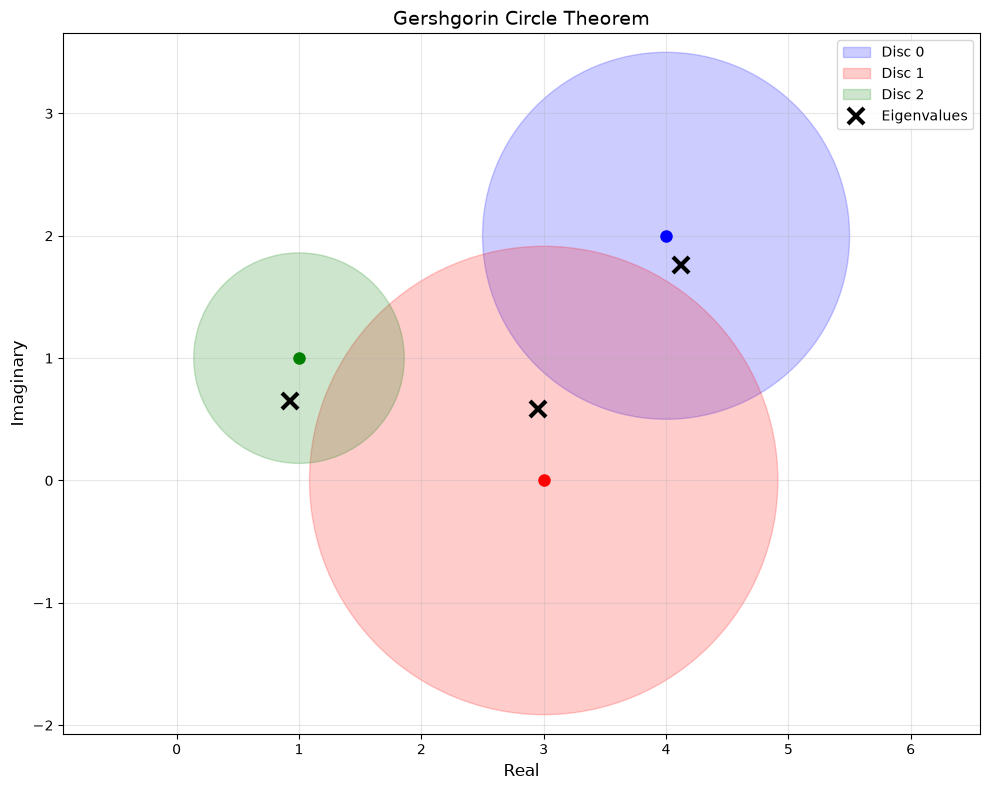

In [15]:
# Define the matrix
A = np.array([[4+2j, 1, 0.5j],
              [0.5, 3, 1-1j],
              [0.2+0.3j, 0.5j, 1+1j]])

# Compute eigenvalues
eigenvalues = np.linalg.eigvals(A)

# Calculate Gershgorin discs.  NOTE: 'j' is reserved for sqrt(-1) throughout this
# text, so row/column loop indices are named i and k.
centers = np.diag(A)
radii = np.array([np.sum(np.abs(A[i, :])) - np.abs(A[i, i]) for i in range(3)])

print("Matrix A:")
print(A)
print("\nEigenvalues:")
for i, eig in enumerate(eigenvalues):
    print(f"lambda_{i} = {eig:.4f}")

print("\nGershgorin Discs:")
for i in range(3):
    print(f"Disc {i}: Center = {centers[i]:.4f}, Radius = {radii[i]:.4f}")

# Verify eigenvalues are in discs
print("\nVerification:")
for i, eig in enumerate(eigenvalues):
    in_disc = [k for k in range(3) if np.abs(eig - centers[k]) <= radii[k]]
    print(f"lambda_{i} is in disc(s): {in_disc}")

# Visualization
fig, ax = plt.subplots(figsize=(10, 8))

# Plot Gershgorin discs
colors = ['blue', 'red', 'green']
for i in range(3):
    circle = plt.Circle((centers[i].real, centers[i].imag),
                        radii[i], color=colors[i],
                        alpha=0.2, label=f'Disc {i}')
    ax.add_patch(circle)
    ax.plot(centers[i].real, centers[i].imag, 'o',
            color=colors[i], markersize=8)

# Plot eigenvalues
ax.plot(eigenvalues.real, eigenvalues.imag, 'kx',
        markersize=12, markeredgewidth=3, label='Eigenvalues')

# Formatting
ax.set_xlabel('Real', fontsize=12)
ax.set_ylabel('Imaginary', fontsize=12)
ax.set_title('Gershgorin Circle Theorem', fontsize=14)
ax.grid(True, alpha=0.3)
ax.axis('equal')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## Gershgorin bounds and conditioning of the tridiagonal family  *(Book §3.11, Exercise 3.27)*
For the $(-1,2,-1)$ tridiagonal matrix, Gershgorin gives $\lambda\in[0,4]$ for every $N$: the boundary rows have radius 1 and the interior rows radius 2, all centered at 2. Comparing against the true spectrum shows how the bound behaves — the upper end is tight, the lower end is not, and it is the ratio of the two that governs the condition number $\kappa=\lambda_{\max}/\lambda_{\min}$, which grows as $O(N^2)$.

In [16]:
for N in (4, 8, 16, 32, 64):
    e = np.linalg.eigh(tridiag(N))[0]
    print(f"N={N:3d}: Gershgorin [0, 4]   actual [{e[0]:.4f}, {e[-1]:.4f}]   "
          f"kappa={e[-1]/e[0]:8.2f}")
print("\nkappa ~ O(N^2): conjugate gradient needs O(sqrt(kappa)) ~ O(N) iterations,")
print("which is why preconditioning matters for large N.")

N=  4: Gershgorin [0, 4]   actual [0.3820, 3.6180]   kappa=    9.47
N=  8: Gershgorin [0, 4]   actual [0.1206, 3.8794]   kappa=   32.16
N= 16: Gershgorin [0, 4]   actual [0.0341, 3.9659]   kappa=  116.46
N= 32: Gershgorin [0, 4]   actual [0.0091, 3.9909]   kappa=  440.69
N= 64: Gershgorin [0, 4]   actual [0.0023, 3.9977]   kappa= 1711.66

kappa ~ O(N^2): conjugate gradient needs O(sqrt(kappa)) ~ O(N) iterations,
which is why preconditioning matters for large N.
